# IBM HR Attrition Exploratory Data Analysis

This notebook explores employee attrition patterns using the IBM HR Analytics Attrition dataset.

The analysis focuses on:
- Overall attrition rate
- Attrition by department
- Overtime vs attrition
- Monthly income vs attrition
- Key HR analytics insights for a data analyst portfolio

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [5]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.columns

Rows: 1470
Columns: 35


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [7]:
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")
missing_values.head(10)

Duplicate rows: 0


Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

In [8]:
overall_attrition_rate = df["Attrition"].value_counts(normalize=True)["Yes"] * 100

print(f"Overall attrition rate: {overall_attrition_rate:.2f}%")

Overall attrition rate: 16.12%


## Overall Attrition Rate

The overall employee attrition rate in this dataset is **16.12%**.

This means roughly 1 in 6 employees in the dataset left the company. This provides a baseline for comparing attrition across departments, overtime status, job roles, and income groups.

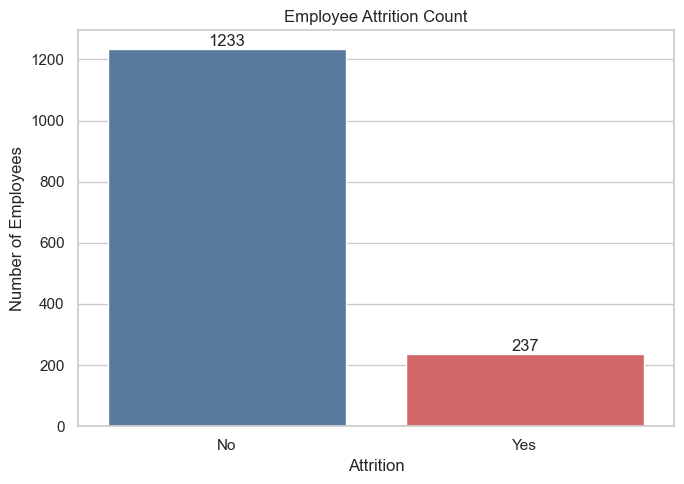

In [9]:
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=attrition_counts.index,
    y=attrition_counts.values,
    hue=attrition_counts.index,
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../charts/overall_attrition_count.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .value_counts(normalize=True)
    .rename("Rate")
    .reset_index()
)

department_attrition_yes = department_attrition[
    department_attrition["Attrition"] == "Yes"
].copy()

department_attrition_yes["Attrition Rate (%)"] = department_attrition_yes["Rate"] * 100

department_attrition_yes = department_attrition_yes.sort_values(
    "Attrition Rate (%)",
    ascending=False
)

department_attrition_yes[["Department", "Attrition Rate (%)"]]

,Department,Attrition Rate (%)
5,Sales,20.627803
1,Human Resources,19.047619
3,Research & Development,13.839750


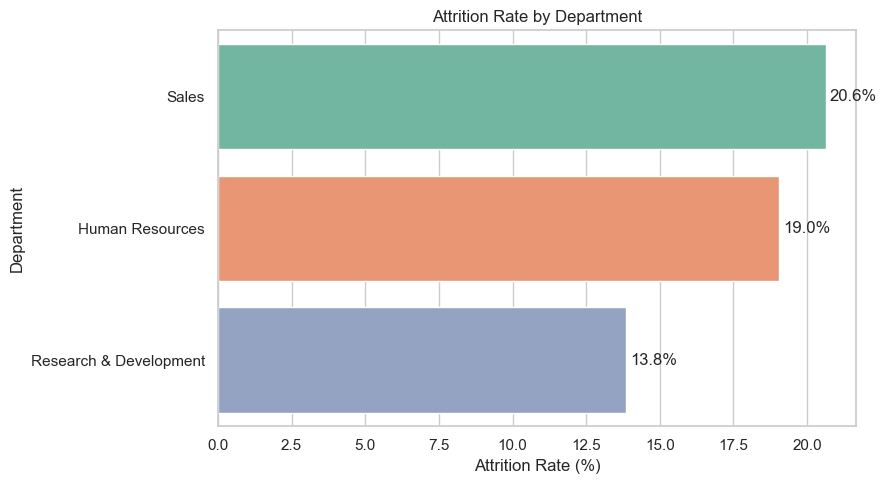

In [11]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=department_attrition_yes,
    x="Attrition Rate (%)",
    y="Department",
    hue="Department",
    palette="Set2",
    legend=False
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../charts/attrition_by_department.png", dpi=300, bbox_inches="tight")
plt.show()

## Attrition by Department

The Sales department has the highest attrition rate among the three departments, followed by Human Resources and Research & Development.

This suggests that employee retention risks may differ by function, and department-level analysis can help HR teams focus deeper investigation on the areas with higher attrition.

In [12]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
    .value_counts(normalize=True)
    .rename("Rate")
    .reset_index()
)

overtime_attrition_yes = overtime_attrition[
    overtime_attrition["Attrition"] == "Yes"
].copy()

overtime_attrition_yes["Attrition Rate (%)"] = overtime_attrition_yes["Rate"] * 100

overtime_attrition_yes = overtime_attrition_yes.sort_values(
    "Attrition Rate (%)",
    ascending=False
)

overtime_attrition_yes[["OverTime", "Attrition Rate (%)"]]

,OverTime,Attrition Rate (%)
3,Yes,30.528846
1,No,10.436433


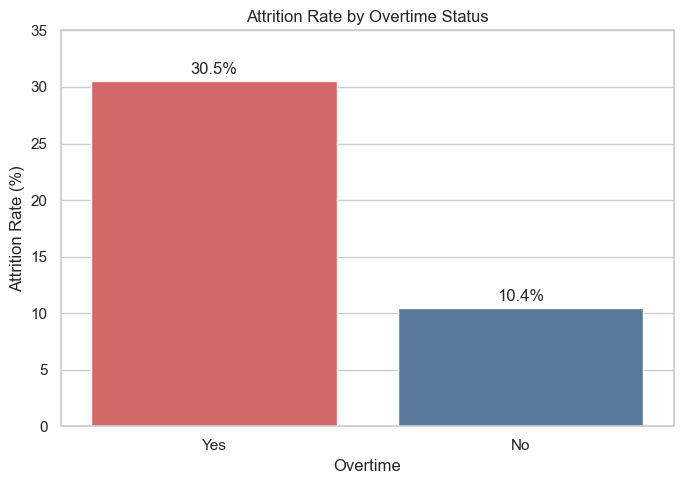

In [13]:
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=overtime_attrition_yes,
    x="OverTime",
    y="Attrition Rate (%)",
    hue="OverTime",
    palette=["#E45756", "#4C78A8"],
    legend=False
)

plt.title("Attrition Rate by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 35)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../charts/attrition_by_overtime.png", dpi=300, bbox_inches="tight")
plt.show()

## Overtime and Attrition

Employees who worked overtime had an attrition rate of **30.53%**, compared with **10.44%** for employees who did not work overtime.

This means overtime employees left at nearly **3x the rate** of non-overtime employees. From a People Analytics perspective, overtime may be an important indicator of workload pressure, burnout risk, or work-life balance challenges.

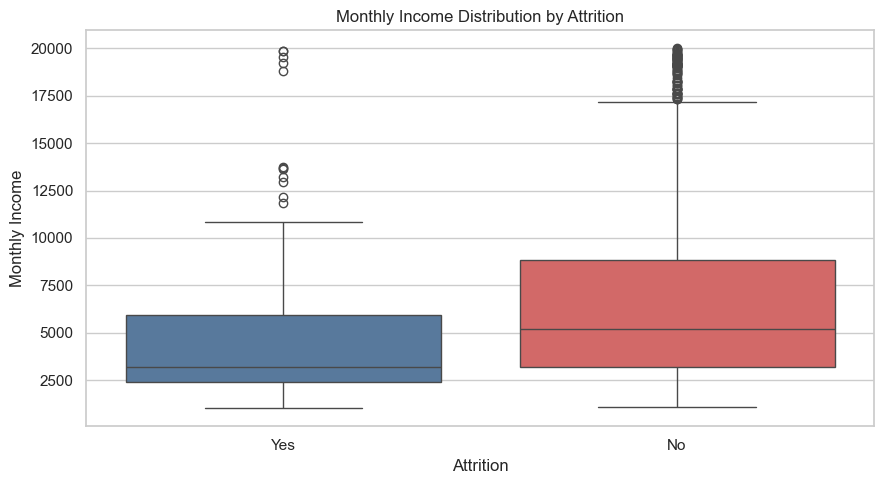

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    hue="Attrition",
    palette=["#4C78A8", "#E45756"],
    legend=False
)

plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.savefig("../charts/income_vs_attrition_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
df["IncomeGroup"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 3000, 6000, 10000, df["MonthlyIncome"].max()],
    labels=["Low income", "Lower-middle income", "Upper-middle income", "High income"],
    include_lowest=True
)

income_attrition = (
    df.groupby("IncomeGroup", observed=True)["Attrition"]
    .value_counts(normalize=True)
    .rename("Rate")
    .reset_index()
)

income_attrition_yes = income_attrition[
    income_attrition["Attrition"] == "Yes"
].copy()

income_attrition_yes["Attrition Rate (%)"] = income_attrition_yes["Rate"] * 100

income_attrition_yes[["IncomeGroup", "Attrition Rate (%)"]]

,IncomeGroup,Attrition Rate (%)
1,Low income,28.607595
3,Lower-middle income,12.716763
5,Upper-middle income,12.000000
7,High income,8.896797


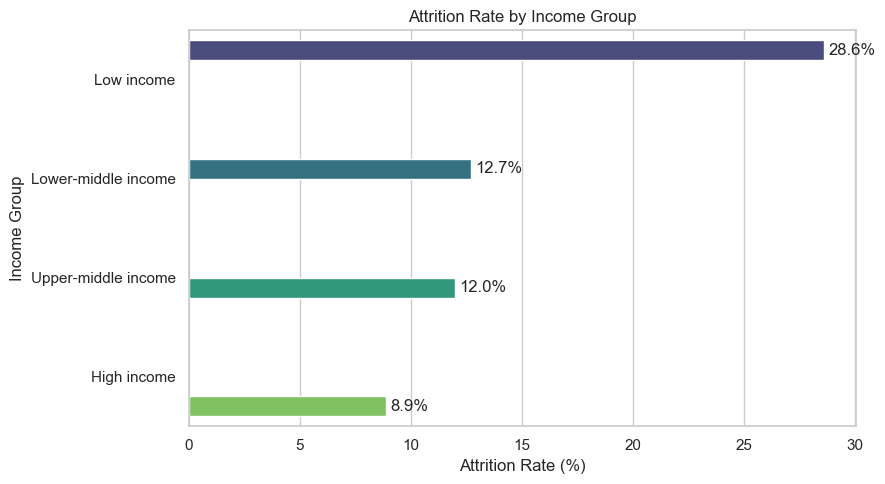

In [16]:
income_attrition_yes = income_attrition_yes.sort_values(
    "Attrition Rate (%)",
    ascending=False
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=income_attrition_yes,
    x="Attrition Rate (%)",
    y="IncomeGroup",
    hue="IncomeGroup",
    palette="viridis",
    legend=False
)

plt.title("Attrition Rate by Income Group")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Income Group")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../charts/attrition_by_income_group.png", dpi=300, bbox_inches="tight")
plt.show()

## Income and Attrition

Employees in the low-income group had the highest attrition rate at approximately **28.61%**.

This suggests that compensation level may be related to employee retention risk. Lower-income employees may have stronger incentives to leave for better-paying opportunities, especially when combined with other factors such as overtime, job role, or career progression.

In [17]:
job_role_attrition = (
    df.groupby("JobRole")["Attrition"]
    .value_counts(normalize=True)
    .rename("Rate")
    .reset_index()
)

job_role_attrition_yes = job_role_attrition[
    job_role_attrition["Attrition"] == "Yes"
].copy()

job_role_attrition_yes["Attrition Rate (%)"] = job_role_attrition_yes["Rate"] * 100

job_role_attrition_yes = job_role_attrition_yes.sort_values(
    "Attrition Rate (%)",
    ascending=False
)

job_role_attrition_yes[["JobRole", "Attrition Rate (%)"]]

,JobRole,Attrition Rate (%)
17,Sales Representative,39.759036
5,Laboratory Technician,23.938224
3,Human Resources,23.076923
15,Sales Executive,17.484663
13,Research Scientist,16.095890
9,Manufacturing Director,6.896552
1,Healthcare Representative,6.870229
7,Manager,4.901961
11,Research Director,2.500000


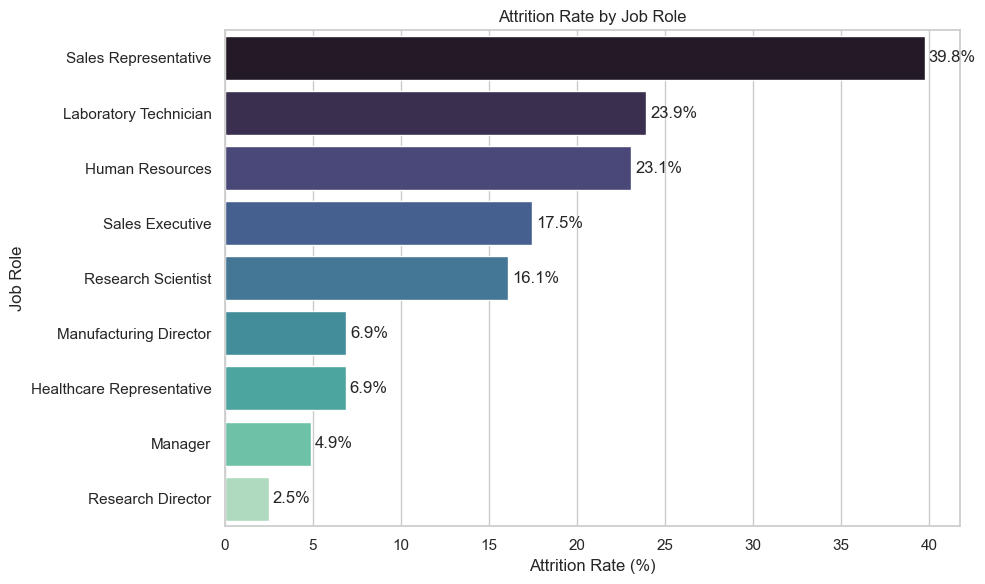

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=job_role_attrition_yes,
    x="Attrition Rate (%)",
    y="JobRole",
    hue="JobRole",
    palette="mako",
    legend=False
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.savefig("../charts/attrition_by_job_role.png", dpi=300, bbox_inches="tight")
plt.show()

## Attrition by Job Role

Sales Representative had the highest attrition rate at approximately **39.76%**.

This is a strong signal for HR teams to investigate role-specific drivers of turnover, such as sales targets, workload, compensation structure, onboarding experience, manager support, or career path clarity.